In [1]:
! pip install opencv-python matplotlib numpy

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def fda_style_transfer(source_img, target_img, beta=0.05):
    h, w, c = source_img.shape
    if target_img.shape[:2] != (h, w):
        target_img = cv2.resize(target_img, (w, h))

    src_fft = np.fft.fft2(source_img, axes=(0, 1)) 
    trg_fft = np.fft.fft2(target_img, axes=(0, 1))

    src_fft_shift = np.fft.fftshift(src_fft, axes=(0, 1))
    trg_fft_shift = np.fft.fftshift(trg_fft, axes=(0, 1))

    src_amplitude = np.abs(src_fft_shift)
    src_phase = np.angle(src_fft_shift)
    trg_amplitude = np.abs(trg_fft_shift)

    mask = np.zeros((h, w, c))
    h_start = int(h * (0.5 - beta / 2))
    h_end = int(h * (0.5 + beta / 2))
    w_start = int(w * (0.5 - beta / 2))
    w_end = int(w * (0.5 + beta / 2))
    mask[h_start:h_end, w_start:w_end, :] = 1

    res_amplitude = trg_amplitude * mask + src_amplitude * (1 - mask)
    res_fft_shift = res_amplitude * np.exp(1j * src_phase)

    res_fft = np.fft.ifftshift(res_fft_shift, axes=(0, 1))
    res_img = np.fft.ifft2(res_fft, axes=(0, 1))
    res_img = np.real(res_img)

    res_img = np.clip(res_img, 0, 255).astype(np.uint8)
    
    return res_img

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


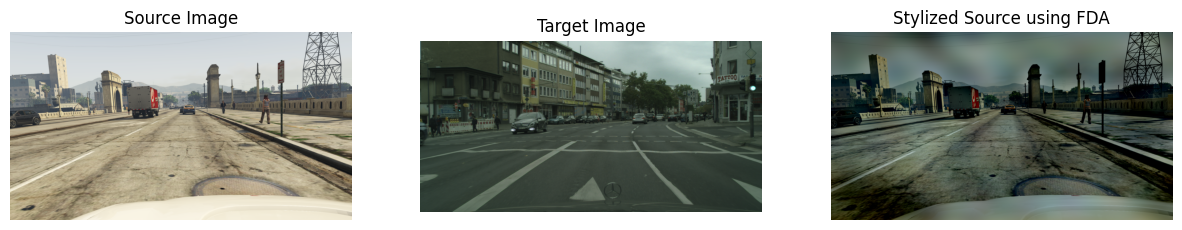

In [4]:
src_path = "drive/MyDrive/CV Images/A1-Q5/source.png"
trg_path = "drive/MyDrive/CV Images/A1-Q5/target.png"

source = cv2.cvtColor(cv2.imread(src_path), cv2.COLOR_BGR2RGB)
target = cv2.cvtColor(cv2.imread(trg_path), cv2.COLOR_BGR2RGB)

stylized = fda_style_transfer(source, target, beta=0.01)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Source Image")
plt.imshow(source)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Target Image")
plt.imshow(target)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Stylized Source using FDA")
plt.imshow(stylized)
plt.axis('off')

plt.show()